In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from tqdm import tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset, Subset


In [ ]:
#Data Augmentation
#Horizontal flip, rotation , Crop
train_dir = "/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset/train/"
import torchvision.transforms.functional as F
import random # Import the random module


class Augmentation:
    def __call__(self,sat,maps):

        if torch.rand(1) < 0.5:
            sat= F.hflip(sat)
            maps = F.hflip(maps)

        rotation_angle = [0,90,180]
        if rotation_angle:
           angle = random.choice(rotation_angle)
        if angle != 0:
            sat = F.rotate(sat, angle)
            maps = F.rotate(maps, angle)

        sat = F.resize(sat, 286)
        maps = F.resize(maps, 286)

        i, j, h, w = transforms.RandomCrop.get_params(sat, output_size=(256, 256))
        sat = F.crop(sat, i, j, h, w)
        maps = F.crop(maps, i, j, h, w)

        return sat,maps

In [ ]:
class Pix2PixDataset(Dataset):
    def __init__(self, root_dir, augment= True):
      self.augment = augment
      self.root_dir = root_dir
      self.image_files = os.listdir(root_dir)
      print(f"Found {len(self.image_files)} files in {root_dir}") # Added print
      self.data = []
      for filename in self.image_files:
          npz_path = os.path.join(self.root_dir, filename)
          try: # Added try-except block
              with np.load(npz_path) as data:
                  self.data.append((data['input'], data['target']))
          except Exception as e: # Added exception handling
              print(f"Error loading {npz_path}: {e}") # Added print for errors
      print(f"Loaded {len(self.data)} data samples.") # Added print


    def __len__(self):
      return len(self.data) # Changed from self.image_files to self.data

    def __getitem__(self, idx):
        input_img, target_img = self.data[idx]
        #normalized te image
        input_img = torch.from_numpy(input_img).float()
        target_img = torch.from_numpy(target_img).float()

        if self.augment:
            augment = Augmentation()
            input_img, target_img = augment(input_img, target_img)

        return input_img, target_img

In [ ]:
train_dataset = Pix2PixDataset("/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset/train/", augment= True )
val_dataset = Pix2PixDataset("/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset/val/", augment=False )
test_dataset = Pix2PixDataset("/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset/test/", augment=False)

train_loader = DataLoader(train_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)


Found 1755 files in /content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset/train/
Loaded 1755 data samples.
Found 219 files in /content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset/val/
Loaded 219 data samples.
Found 220 files in /content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset/test/
Loaded 220 data samples.


In [ ]:
test_loader = DataLoader(test_dataset, batch_size=64)

Input shape: (3, 256, 256) Min: -1.0 Max: 1.0
Target shape: (3, 256, 256) Min: 0.26274514 Max: 1.0


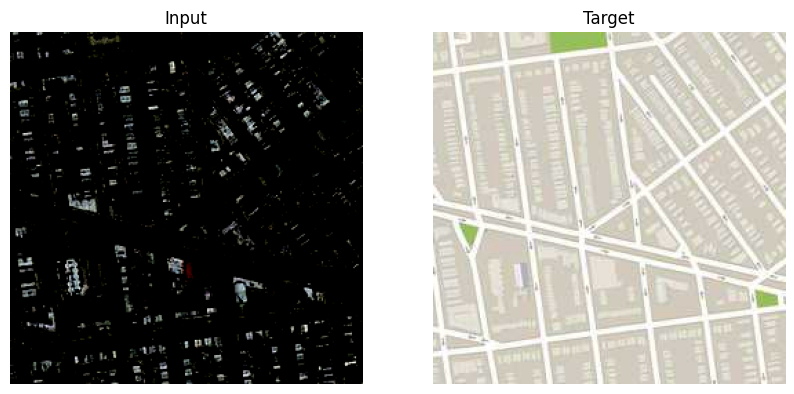

In [ ]:
npz_path = "/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset/train/1.npz"


data = np.load(npz_path)
input_img = data['input']
target_img = data['target']


print("Input shape:", input_img.shape, "Min:", input_img.min(), "Max:", input_img.max())
print("Target shape:", target_img.shape, "Min:", target_img.min(), "Max:", target_img.max())


if input_img.shape[0] == 3:
    input_img = np.transpose(input_img, (1, 2, 0))
if target_img.shape[0] == 3:
    target_img = np.transpose(target_img, (1, 2, 0))

if input_img.max() > 1:
    input_img = input_img / 255.0
if target_img.max() > 1:
    target_img = target_img / 255.0


fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(np.clip(input_img, 0, 1))
axs[0].set_title("Input")
axs[0].axis('off')
axs[1].imshow(np.clip(target_img, 0, 1))
axs[1].set_title("Target")
axs[1].axis('off')
plt.show()

In [ ]:
import torch

# Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move model to device
model.to(device)

def train(model, train_loader, val_loader, epochs=20):
    model = model.to(device)
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        train_loss = running_train_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item()

        val_loss = running_val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses


Using device: cuda


In [ ]:
import matplotlib.pyplot as plt

def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('L1 Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


Epoch 1: 100%|██████████| 28/28 [00:46<00:00,  1.67s/it]


[1/10] Train Loss: 0.0983 | Val Loss: 0.1009


Epoch 2: 100%|██████████| 28/28 [00:45<00:00,  1.63s/it]


[2/10] Train Loss: 0.0943 | Val Loss: 0.0974


Epoch 3: 100%|██████████| 28/28 [00:45<00:00,  1.64s/it]


...

[8/10] Train Loss: 0.0836 | Val Loss: 0.0866


Epoch 9: 100%|██████████| 28/28 [00:45<00:00,  1.63s/it]


[9/10] Train Loss: 0.0819 | Val Loss: 0.0851


Epoch 10: 100%|██████████| 28/28 [00:45<00:00,  1.63s/it]


[10/10] Train Loss: 0.0791 | Val Loss: 0.0862


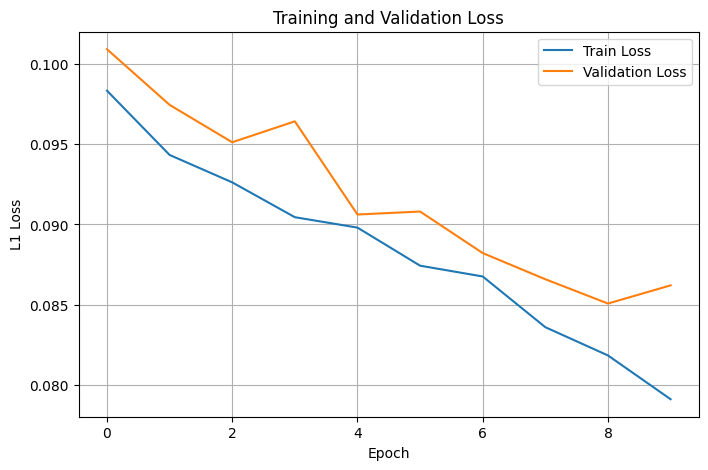

In [ ]:
train_losses, val_losses = train(model, train_loader, val_loader, epochs=10)
plot_loss(train_losses, val_losses)
torch.save(model.state_dict(), "unet_l1_final.pth")


In [ ]:
def compute_iou(preds, targets, threshold=0.5):
    preds = (preds > threshold).float()
    targets = (targets > threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection + 1e-6

    iou = intersection / union
    return iou.mean().item()


In [ ]:
def evaluate_iou(model, test_loader):
    model.eval()
    model.to(device)
    total_iou = 0.0
    count = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            iou = compute_iou(outputs, targets)
            total_iou += iou
            count += 1

    avg_iou = total_iou / count
    print(f"Average IoU on test set: {avg_iou:.4f}")
    return avg_iou

# Example usage
#evaluate_iou(model, test_loader)


In [ ]:
import torch
import matplotlib.pyplot as plt
import random
import numpy as np

def denormalize(img):
    # Convert from [-1, 1] to [0, 1]
    return (img + 1) / 2.0

def show_generator_prediction(model, test_loader):
    model.eval()
    model.to(device)

    # Get a random batch
    inputs, targets = next(iter(test_loader))
    rand_idx = random.randint(0, inputs.size(0) - 1)

    inputs = inputs.to(device)
    with torch.no_grad():
        preds = model(inputs)

    # Get CPU tensors
    input_img = inputs[rand_idx].cpu().permute(1, 2, 0).numpy()
    target_img = targets[rand_idx].cpu().permute(1, 2, 0).numpy()
    pred_img = preds[rand_idx].cpu().permute(1, 2, 0).numpy()

    # De-normalize if using Tanh activation
    input_img = denormalize(input_img)
    target_img = denormalize(target_img)
    pred_img = denormalize(pred_img)

    # Clip for safe display
    input_img = np.clip(input_img, 0, 1)
    target_img = np.clip(target_img, 0, 1)
    pred_img = np.clip(pred_img, 0, 1)

    # Plot images
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(input_img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(target_img)
    plt.title("Target Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_img)
    plt.title("Predicted Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example usage after training:
#show_generator_prediction(model, test_loader)


Epoch 1: 100%|██████████| 28/28 [00:46<00:00,  1.65s/it]


[1/20] Train Loss: 0.0749 | Val Loss: 0.0796


Epoch 2: 100%|██████████| 28/28 [00:45<00:00,  1.64s/it]


[2/20] Train Loss: 0.0756 | Val Loss: 0.0823


Epoch 3: 100%|██████████| 28/28 [00:45<00:00,  1.63s/it]


...

[18/20] Train Loss: 0.0660 | Val Loss: 0.0715


Epoch 19: 100%|██████████| 28/28 [00:45<00:00,  1.63s/it]


[19/20] Train Loss: 0.0659 | Val Loss: 0.0732


Epoch 20: 100%|██████████| 28/28 [00:45<00:00,  1.63s/it]


[20/20] Train Loss: 0.0661 | Val Loss: 0.0709


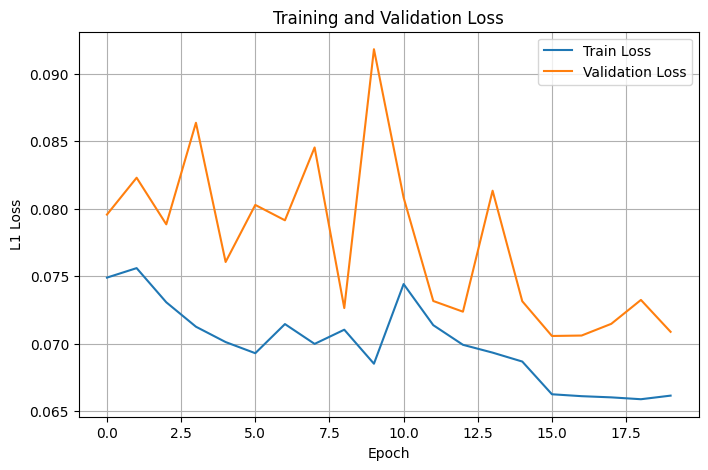

In [ ]:
train_losses, val_losses = train(model, train_loader, val_loader, epochs=20)
plot_loss(train_losses, val_losses)
torch.save(model.state_dict(), "unet_l1_20_epochs.pth")


Average IoU on test set: 0.9619


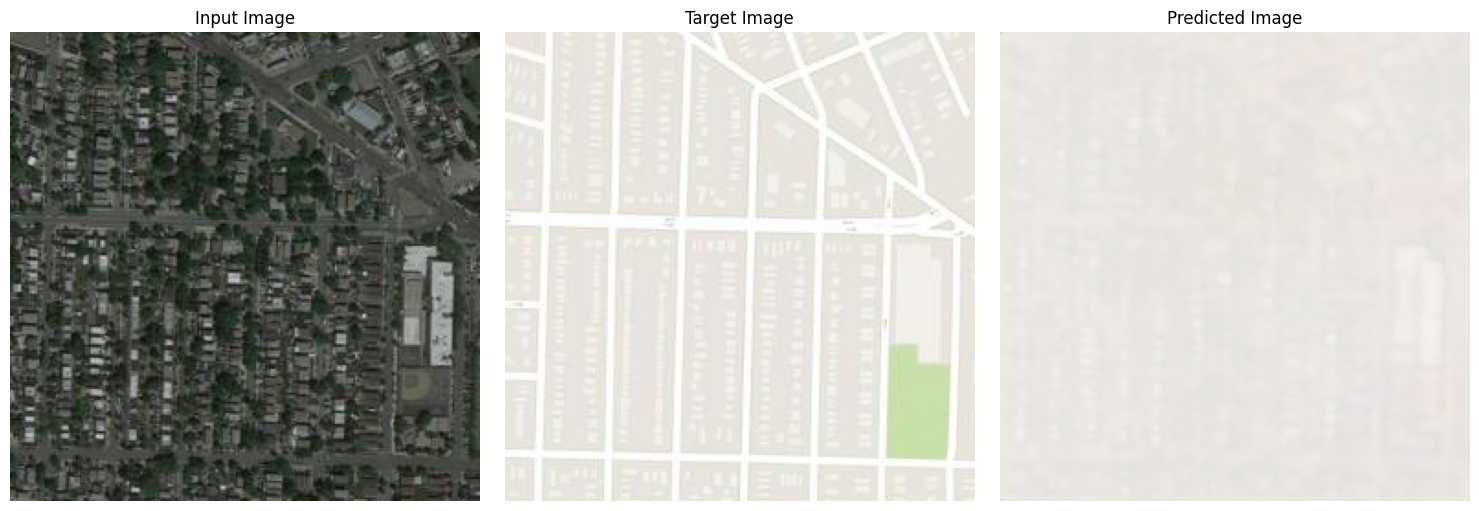

In [ ]:
evaluate_iou(model, test_loader)
show_generator_prediction(model, test_loader)

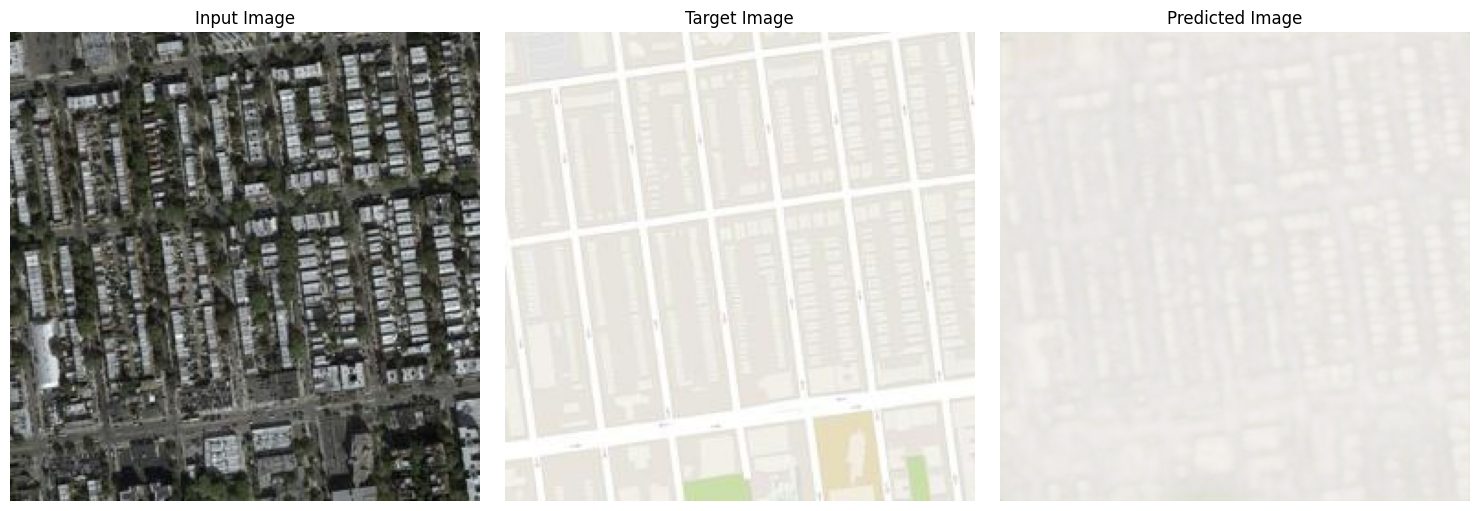

In [ ]:
show_generator_prediction(model, test_loader)

In [ ]:
class UNet(nn.Module):
    def __init__(self, img_channels=3):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels, dropout=0.0):
            layers = [
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            ]
            if dropout > 0:
                layers.insert(2, nn.Dropout(dropout))
            return nn.Sequential(*layers)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Contracting path
        self.c1 = conv_block(img_channels, 16, dropout=0.1)
        self.c2 = conv_block(16, 32, dropout=0.1)
        self.c3 = conv_block(32, 64, dropout=0.2)
        self.c4 = conv_block(64, 128, dropout=0.2)
        self.c5 = conv_block(128, 256, dropout=0.3)

        # Expansive path
        self.up6 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.c6 = conv_block(256, 128, dropout=0.2)

        self.up7 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.c7 = conv_block(128, 64, dropout=0.2)

        self.up8 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.c8 = conv_block(64, 32, dropout=0.1)

        self.up9 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.c9 = conv_block(32, 16, dropout=0.1)

        self.out = nn.Conv2d(16, 3, kernel_size=1)

    def forward(self, x):
        # Encoder
        c1 = self.c1(x)
        p1 = self.pool(c1)

        c2 = self.c2(p1)
        p2 = self.pool(c2)

        c3 = self.c3(p2)
        p3 = self.pool(c3)

        c4 = self.c4(p3)
        p4 = self.pool(c4)

        c5 = self.c5(p4)

        # Decoder
        u6 = self.up6(c5)
        u6 = torch.cat([u6, c4], dim=1)
        c6 = self.c6(u6)

        u7 = self.up7(c6)
        u7 = torch.cat([u7, c3], dim=1)
        c7 = self.c7(u7)

        u8 = self.up8(c7)
        u8 = torch.cat([u8, c2], dim=1)
        c8 = self.c8(u8)

        u9 = self.up9(c8)
        u9 = torch.cat([u9, c1], dim=1)
        c9 = self.c9(u9)

        out = self.out(c9)
        return torch.sigmoid(out)

model = UNet()
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

def show_unet_prediction(model, test_loader):
    model.eval()
    model.to(device)

    # Fetch one random batch
    inputs, targets = next(iter(test_loader))
    rand_idx = random.randint(0, inputs.size(0) - 1)

    inputs, targets = inputs.to(device), targets.to(device)
    with torch.no_grad():
        preds = model(inputs)

    # Extract one sample
    input_img = inputs[rand_idx].cpu().permute(1, 2, 0).numpy()
    target_img = targets[rand_idx].cpu().permute(1, 2, 0).numpy()
    pred_img = preds[rand_idx].cpu().permute(1, 2, 0).numpy()

    # Clip predictions and inputs to [0, 1] for imshow
    input_img = np.clip(input_img, 0, 1)
    target_img = np.clip(target_img, 0, 1)
    pred_img = np.clip(pred_img, 0, 1)

    # Plot input, ground truth, prediction
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(input_img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(target_img)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_img)
    plt.title("Predicted Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


Epoch 1: 100%|██████████| 28/28 [00:25<00:00,  1.10it/s]


[1/10] Train Loss: 0.2015 | Val Loss: 0.1559


Epoch 2: 100%|██████████| 28/28 [00:25<00:00,  1.09it/s]


[2/10] Train Loss: 0.1207 | Val Loss: 0.1092


Epoch 3: 100%|██████████| 28/28 [00:25<00:00,  1.10it/s]


...

[8/10] Train Loss: 0.0945 | Val Loss: 0.1001


Epoch 9: 100%|██████████| 28/28 [00:25<00:00,  1.09it/s]


[9/10] Train Loss: 0.0931 | Val Loss: 0.0977


Epoch 10: 100%|██████████| 28/28 [00:25<00:00,  1.10it/s]


[10/10] Train Loss: 0.0907 | Val Loss: 0.0927


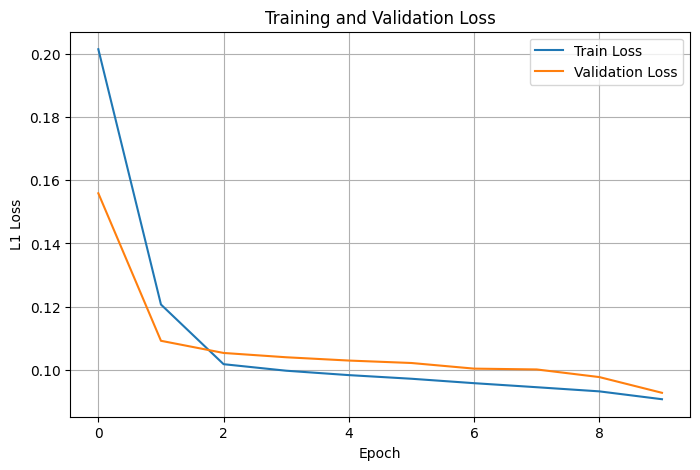

Average IoU on test set: 0.9340


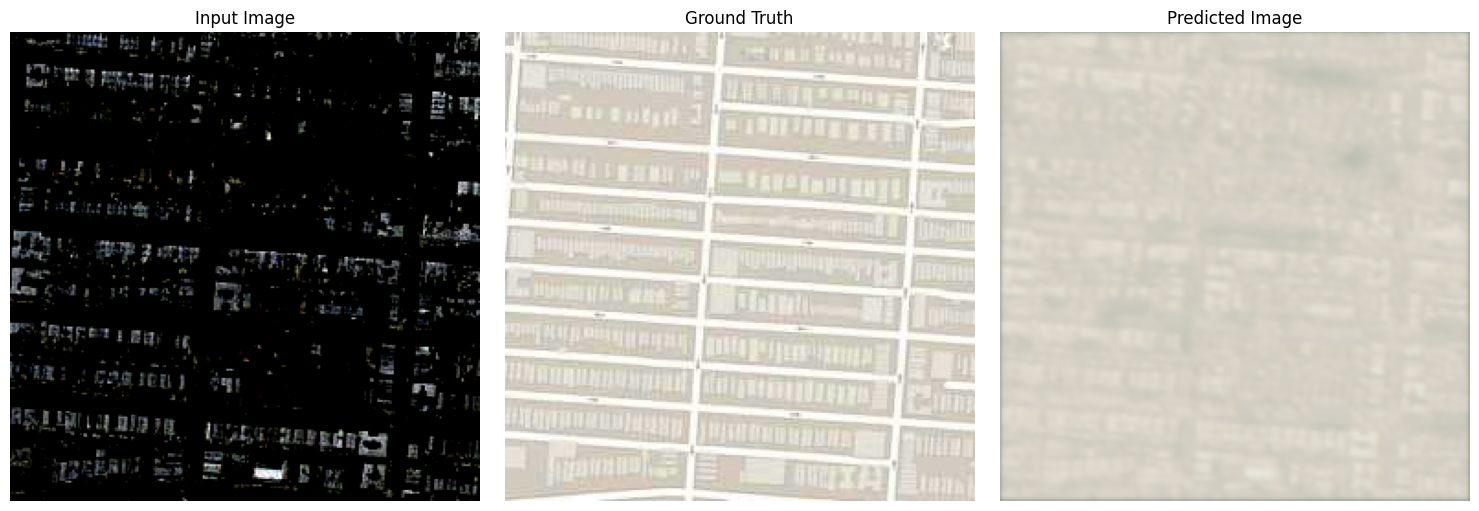

In [ ]:
train_losses, val_losses = train(model, train_loader, val_loader, epochs=10)
plot_loss(train_losses, val_losses)
torch.save(model.state_dict(), "unet_l1_UNet.pth")
evaluate_iou(model, test_loader)
show_unet_prediction(model, test_loader)

Epoch 1: 100%|██████████| 28/28 [00:26<00:00,  1.08it/s]


[1/30] Train Loss: 0.0867 | Val Loss: 0.0823


Epoch 2: 100%|██████████| 28/28 [00:26<00:00,  1.07it/s]


[2/30] Train Loss: 0.0837 | Val Loss: 0.0802


Epoch 3: 100%|██████████| 28/28 [00:25<00:00,  1.09it/s]


...

[28/30] Train Loss: 0.0663 | Val Loss: 0.0711


Epoch 29: 100%|██████████| 28/28 [00:25<00:00,  1.10it/s]


[29/30] Train Loss: 0.0661 | Val Loss: 0.0692


Epoch 30: 100%|██████████| 28/28 [00:25<00:00,  1.11it/s]


[30/30] Train Loss: 0.0662 | Val Loss: 0.0712


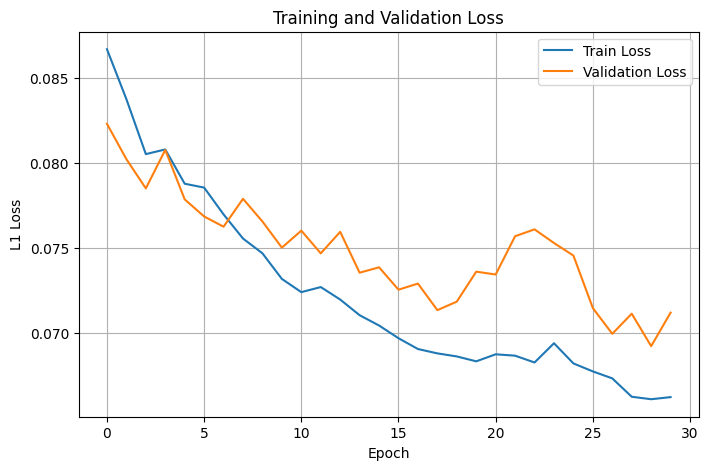

Average IoU on test set: 0.9580


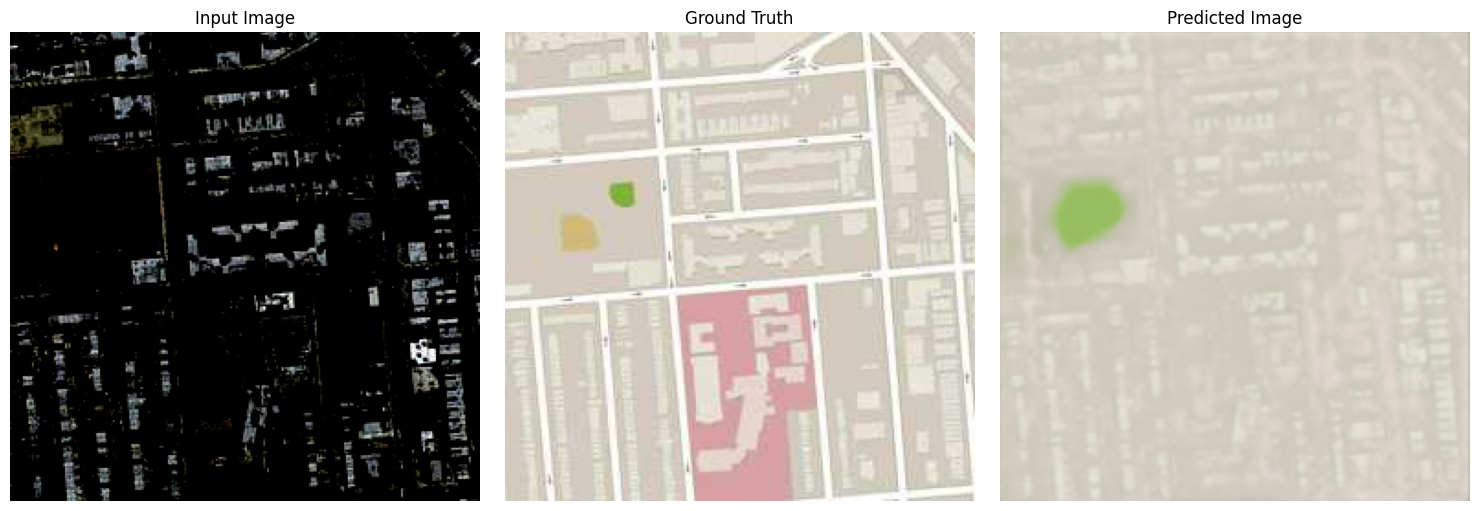

In [ ]:
train_losses, val_losses = train(model, train_loader, val_loader, epochs=30)
plot_loss(train_losses, val_losses)
torch.save(model.state_dict(), "unet_l1_UNet_30.pth")
evaluate_iou(model, test_loader)
show_unet_prediction(model, test_loader)

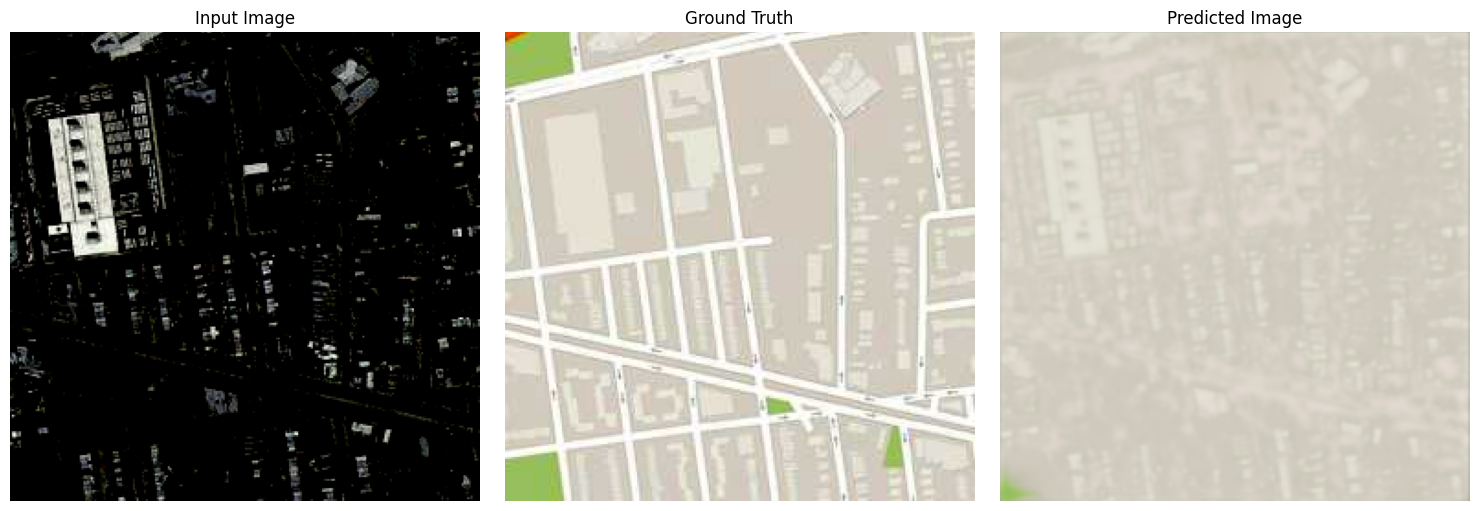

In [ ]:
show_unet_prediction(model, test_loader)

In [ ]:
evaluate_iou(model, test_loader, device)

Average IoU over test set: 0.9580


0.9579763859510422

In [ ]:
def evaluate_l1_loss(generator, val_loader, device=None):
    """
    Computes the average L1 loss (MAE) on the validation set.

    Args:
        generator (nn.Module): Trained generator/model.
        val_loader (DataLoader): Validation DataLoader.
        device (torch.device, optional): Device to run on. Default uses CUDA if available.

    Returns:
        float: Average L1 loss.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    generator = generator.to(device)
    generator.eval()

    criterion = nn.L1Loss().to(device)
    total_l1_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for input_images, target_images in val_loader:
            input_images = input_images.to(device)
            target_images = target_images.to(device)

            fake_images = generator(input_images)
            loss = criterion(fake_images, target_images)

            total_l1_loss += loss.item()
            num_batches += 1

    average_l1_loss = total_l1_loss / num_batches
    print(f"Average L1 loss for the validation set: {average_l1_loss:.4f}")
    return average_l1_loss


In [ ]:
evaluate_l1_loss(generator=model, val_loader=val_loader)

Average L1 loss for the validation set: 0.0712


0.07119680196046829

In [ ]:
#Data Augmentation New data
#Horizontal flip, rotation , Crop
train_dir = "/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset_new/train/"
import torchvision.transforms.functional as F
import random # Import the random module


class Augmentation:
    def __call__(self,sat,maps):

        if torch.rand(1) < 0.5:
            sat= F.hflip(sat)
            maps = F.hflip(maps)

        rotation_angle = [0,90,180]
        if rotation_angle:
           angle = random.choice(rotation_angle)
        if angle != 0:
            sat = F.rotate(sat, angle)
            maps = F.rotate(maps, angle)

        sat = F.resize(sat, 286)
        maps = F.resize(maps, 286)

        i, j, h, w = transforms.RandomCrop.get_params(sat, output_size=(256, 256))
        sat = F.crop(sat, i, j, h, w)
        maps = F.crop(maps, i, j, h, w)

        return sat,maps

In [ ]:
class Pix2PixDataset(Dataset):
    def __init__(self, root_dir, augment= True):
      self.augment = augment
      self.root_dir = root_dir
      self.image_files = os.listdir(root_dir)
      print(f"Found {len(self.image_files)} files in {root_dir}") # Added print
      self.data = []
      for filename in self.image_files:
          npz_path = os.path.join(self.root_dir, filename)
          try: # Added try-except block
              with np.load(npz_path) as data:
                  self.data.append((data['input'], data['target']))
          except Exception as e: # Added exception handling
              print(f"Error loading {npz_path}: {e}") # Added print for errors
      print(f"Loaded {len(self.data)} data samples.") # Added print


    def __len__(self):
      return len(self.data) # Changed from self.image_files to self.data

    def __getitem__(self, idx):
        input_img, target_img = self.data[idx]
        #normalized te image
        input_img = torch.from_numpy(input_img).float()
        target_img = torch.from_numpy(target_img).float()

        if self.augment:
            augment = Augmentation()
            input_img, target_img = augment(input_img, target_img)

        return input_img, target_img

In [ ]:
train_dataset = Pix2PixDataset("/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset_new/train/", augment= True )
val_dataset = Pix2PixDataset("/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset_new/val/", augment=False )
test_dataset = Pix2PixDataset("/content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset_new/test/", augment=False)

train_loader = DataLoader(train_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

Found 2216 files in /content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset_new/train/
Error loading /content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset_new/train/633_1.jpg.npz: No data left in file
Loaded 2215 data samples.
Found 277 files in /content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset_new/val/
Loaded 277 data samples.
Found 277 files in /content/drive/My Drive/Colab Notebooks/APS360/Project/Dataset/pix2pix_np_splitdataset_new/test/
Loaded 277 data samples.


In [ ]:
model = UNet()
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Epoch 1: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s]


[1/10] Train Loss: 0.1789 | Val Loss: 0.1104


Epoch 2: 100%|██████████| 35/35 [00:31<00:00,  1.10it/s]


[2/10] Train Loss: 0.1026 | Val Loss: 0.1020


Epoch 3: 100%|██████████| 35/35 [00:31<00:00,  1.12it/s]


...

[8/10] Train Loss: 0.0892 | Val Loss: 0.0878


Epoch 9: 100%|██████████| 35/35 [00:32<00:00,  1.09it/s]


[9/10] Train Loss: 0.0858 | Val Loss: 0.0851


Epoch 10: 100%|██████████| 35/35 [00:31<00:00,  1.10it/s]


[10/10] Train Loss: 0.0846 | Val Loss: 0.0831


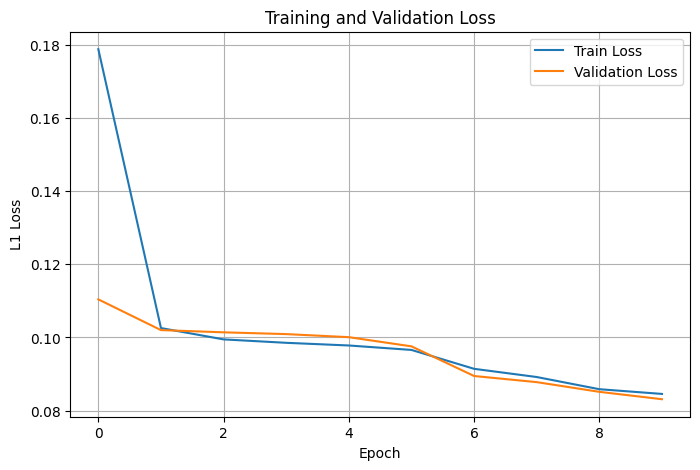

In [ ]:
train_losses, val_losses = train(model, train_loader, val_loader, epochs=10)
plot_loss(train_losses, val_losses)
torch.save(model.state_dict(), "unet_newdata_1.pth")

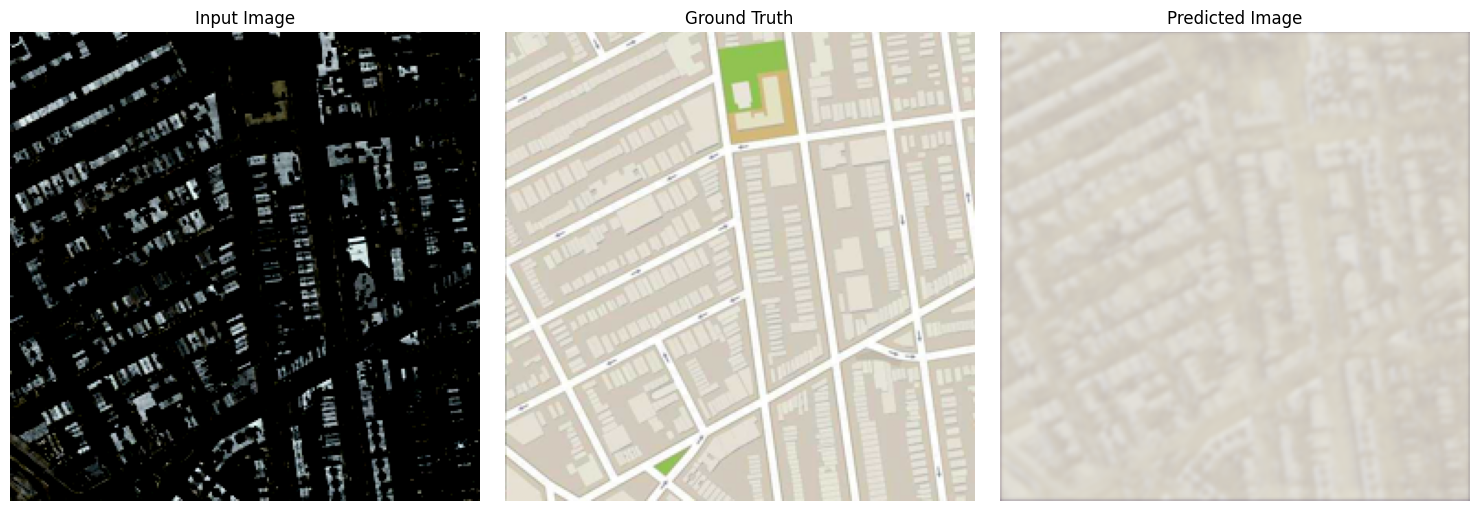

In [ ]:
show_unet_prediction(model, test_loader)

In [ ]:
evaluate_iou(model, test_loader)

Average IoU on test set: 0.9513


0.9512736558914184

In [ ]:
evaluate_l1_loss(generator=model, val_loader=val_loader)

Average L1 loss for the validation set: 0.0831


0.0831016629934311

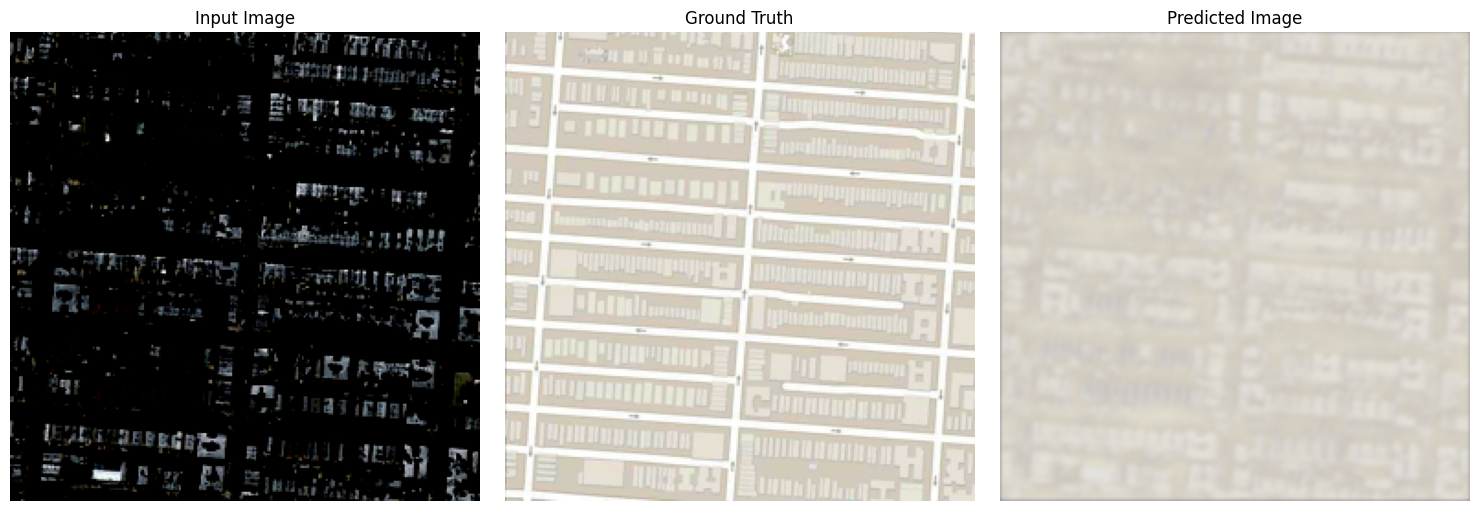

In [ ]:
show_unet_prediction(model, test_loader)

Epoch 1: 100%|██████████| 35/35 [00:33<00:00,  1.03it/s]


[1/30] Train Loss: 0.2194 | Val Loss: 0.1076


Epoch 2: 100%|██████████| 35/35 [00:33<00:00,  1.05it/s]


[2/30] Train Loss: 0.1048 | Val Loss: 0.1031


Epoch 3: 100%|██████████| 35/35 [00:33<00:00,  1.04it/s]


...

[28/30] Train Loss: 0.0796 | Val Loss: 0.0806


Epoch 29: 100%|██████████| 35/35 [00:32<00:00,  1.07it/s]


[29/30] Train Loss: 0.0787 | Val Loss: 0.0838


Epoch 30: 100%|██████████| 35/35 [00:32<00:00,  1.09it/s]


[30/30] Train Loss: 0.0772 | Val Loss: 0.0795


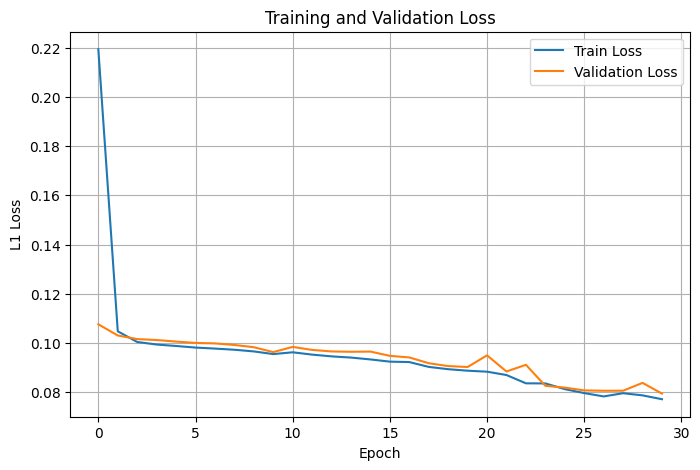

In [ ]:
train_losses, val_losses = train(model, train_loader, val_loader, epochs=30)
plot_loss(train_losses, val_losses)
torch.save(model.state_dict(), "unet_newdata_2.pth")

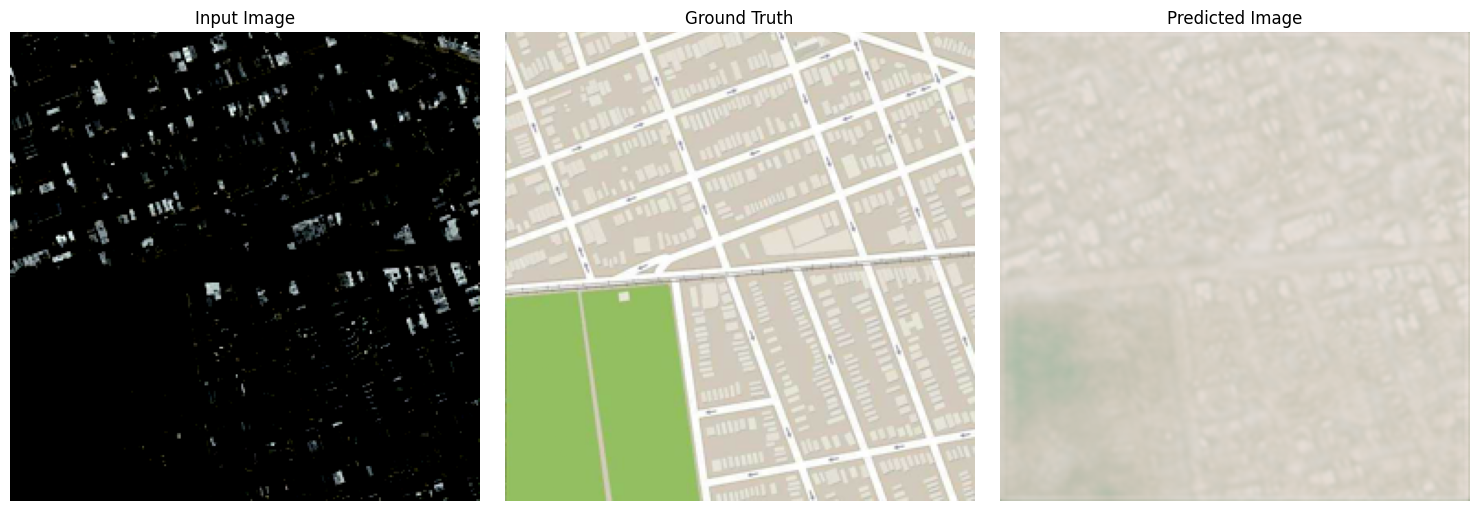

In [ ]:
show_unet_prediction(model, test_loader)

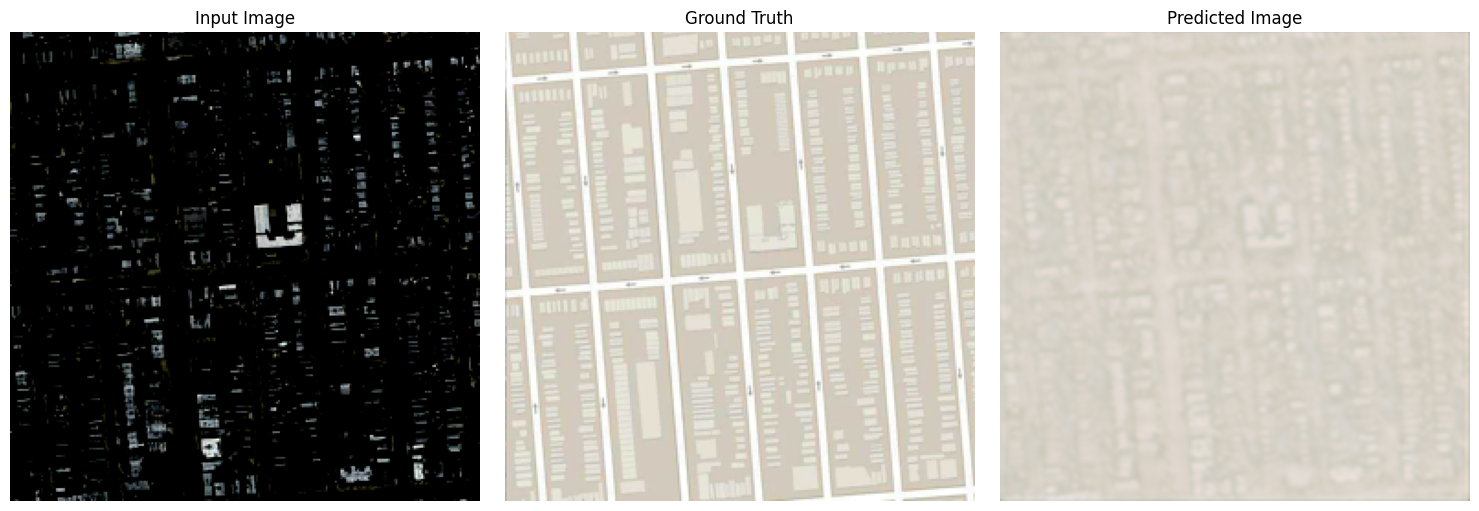

In [ ]:
show_unet_prediction(model, test_loader)

In [ ]:
evaluate_iou(model, test_loader)

Average IoU on test set: 0.9521


0.9521066665649414

In [ ]:
evaluate_l1_loss(generator=model, val_loader=val_loader)

Average L1 loss for the validation set: 0.0795


0.07946221232414245

In [ ]:
#load model and weight
model = UNet(img_channels=3).to(device)

# Load weights
model.load_state_dict(torch.load("unet_newdata_2.pth", map_location=device))
model.eval()

UNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.1, inplace=False)
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
  )
  (c2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.1, inplace=False)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
  )
  (c3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.2, inplace=False)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
  )
  (c4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1)

In [ ]:
###Quantitative results
#PNSR (Peak signal-to-noise ratio): checks max error between pixels, checks noise
#SSIM (Structural similarity index): checks for similar structure


import torch
from skimage.metrics import structural_similarity as ssim
import numpy as np

def psnr(pred, target, max_val=1.0):
    """Peak Signal-to-Noise Ratio"""
    EPS = 1e-8
    mse = torch.mean((pred - target) ** 2)
    return 20 * torch.log10(max_val / torch.sqrt(mse + EPS))

def ssim_calc(pred, target):
    """Structural Similarity Index"""
    # Ensure values are in [0,1]
    pred = pred.clamp(0, 1).cpu().numpy()
    target = target.clamp(0, 1).cpu().numpy()

    # Transpose from (C,H,W) to (H,W,C) if needed
    if pred.ndim == 3:
        pred = np.transpose(pred, (1, 2, 0))
        target = np.transpose(target, (1, 2, 0))
        return ssim(pred, target, channel_axis=2, data_range=1.0)
    else:
        return ssim(pred, target, data_range=1.0)


In [ ]:
from torch import nn

criterion = nn.L1Loss()
total_l1_loss = 0
total_psnr = 0
total_ssim = 0
num_batches = 0
num_images = 0

with torch.no_grad():
    for input_images, target_images in val_loader:
        input_images, target_images = input_images.to(device), target_images.to(device)
        generated_images = model(input_images)

        # L1 Loss
        loss = criterion(generated_images, target_images)
        total_l1_loss += loss.item()

        # Per-image PSNR and SSIM
        batch_size = generated_images.size(0)
        for i in range(batch_size):
            psnr_value = psnr(generated_images[i], target_images[i])
            ssim_value = ssim_calc(generated_images[i], target_images[i])
            total_psnr += psnr_value.item()
            total_ssim += ssim_value

        num_batches += 1
        num_images += batch_size

# Averages
average_l1_loss = total_l1_loss / num_batches
average_psnr = total_psnr / num_images
average_ssim = total_ssim / num_images

print("Validation Dataset Results")
print(f"L1 loss: {average_l1_loss:.4f}")
print(f"PSNR: {average_psnr:.4f}")
print(f"SSIM: {average_ssim:.4f}")


Validation Dataset Results
L1 loss: 0.0795
PSNR: 19.0383
SSIM: 0.4843
